In [2]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10, e
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

%matplotlib inline

# Enable importing from modules in top-level directory
from sys import path
if path[0] != '..': path.insert(0, '..')

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>


# Poler og Nullpunkt i Z-planet

* **Emne AIS2102 - Dynamiske System**
* **26. Januar 2026**
* **Underviser: Kai Erik Hoff**

## Tema:
* Repetisjon Tidsdiskrete LTI-system
* Kontinuerlige LTI-system, laplacetransformasjon og transferfunksjonen $H(s)$
* Diskrete LTI-system, Z-transformasjon og transferfunksjonen $H(z)$
* Analyse av Transferfunksjon $H(z)$ 
* Transferfunksjon og frekvensrespons

# Oppsummering


* Analyse av tidsdiskrete system utføres med *Z-transformasjon*
    * "Mapper" systemet til $z$-planet basert på hva responsen til et signal på formen $z^{k}$.
    
    
* Sammenhengen mellom $s$-planet for laplace og $z$-planet fremgår av substitusjonen
$$z = e^{s \cdot T_s}$$
    * Frekvensaksen i $s$-planet avgrenses til $-\frac{F_s}{2} < f < \frac{F_s}{2}$ og "pakkes" rundt enhetssirkelen.
    * Venstre halvplan i $s$-planet flyttes til innsiden av enhetssirkelen på $z$-planet.
    
    
* Z-transforamsjon omformer en *differanseligning* til en *algebraisk ligning*
$$\begin{align}
a_0\cdot y[n] + a_1 \cdot y[n-1] + \ldots + a_N\cdot y[n-N] &= b_0\cdot x[n] + b_1 \cdot x[n-1] + \ldots + b_N\cdot x[n-M] \\
& \Downarrow \text{Z-transformasjon} \\
Y(z)\left(a_0 + a_1 \cdot z^{-1} + \ldots + a_N\cdot z^{-N} \right) &= X(z)\left(b_0 + b_1 \cdot z^{-1} + \ldots + b_N\cdot z^{-M} \right)
\end{align}$$


# Visualisering av $H(z)$

* $H(z)$ funksjon av et komplekst tall.
    * "Gain" i transferfunksjonen ofte av størst interesse
    * Et "Surface Plot" av $|H(z)|$ vil kunne gi informasjon om forsterkningen av ulike typer signal.
    * Amplituderesponsen vil kunne leses av ved å studere konturene langs enhetssirkelen.

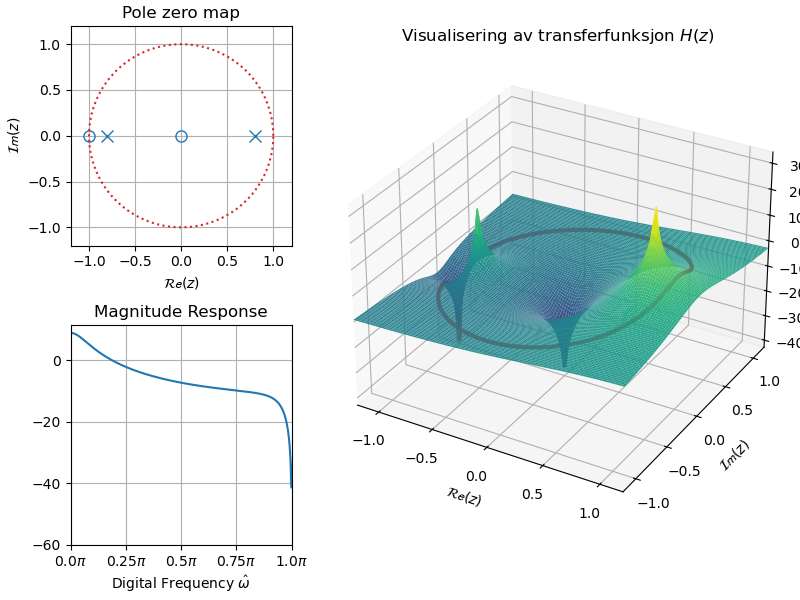

In [14]:
from demos import visualizeTF
# Filter fra regneeksempel 1:
b = [0.5, 0.5] 
a = [1, 0, -0.64]
#plt.close(4); plt.figure(4, figsize=(9,6))
visualizeTF(b, a) # Ikke standardfunksjon, definert i kildekoden til forelesningen.

# Poler og nullpunkt
* $H(z)$ kan alternativt skrives på følgende form:
$$H(z) = \frac{z^M\cdot b_0 + z^{M-1}\cdot b_1 + \cdots + b_M}{z^N\cdot a_0 + z^{N-1}\cdot a_1 + \cdots + a_N}\cdot z^{N-M}$$
### Nullpunkt:
* Verdier av $z$ der:
$$
\begin{align}
H(z) &= 0\\
\text{dvs:} &\downarrow\\
{z^M\cdot b_0 + z^{M-1}\cdot b_1 + \cdots + b_M} &= 0
\end{align}
$$
* Å løse ligningen med hensyn på $z$ gir $M$ mulige løsninger i nullpunktene $z_k \in \{z_1, z_2, \ldots, z_M\}$
    * NB! Dersom $N>M$, vil vi også ha $N-M$ nullpunkt i $z=0$.

# Poler og nullpunkt
* $H(z)$ kan alternativt skrives på følgende form:
$$H(z) = \frac{z^M\cdot b_0 + z^{M-1}\cdot b_1 + \cdots + b_M}{z^N\cdot a_0 + z^{N-1}\cdot a_1 + \cdots + a_N}\cdot z^{N-M}$$
### Poler:
* Verdier av $z$ der:
$$
\begin{align}
\lim_{z\rightarrow p} \left( |H(z)|\right) &= \infty\\
\text{dvs:} &\downarrow\\
{z^N\cdot a_0 + z^{N-1}\cdot a_1 + \cdots + a_N} &= 0
\end{align}
$$
* Å løse ligningen med hensyn på $z$ gir $N$ mulige løsninger i polene $z_k \in \{p_1, p_2, \ldots, p_N\}$
    * NB! Dersom $N<M$, vil vi også ha $M-N$ poler i $z=0$.

# Stabilitet

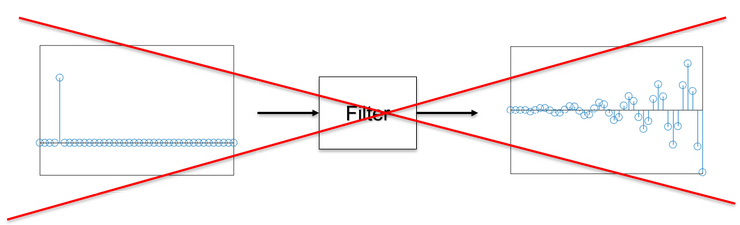

* Definisjon i tidsdomenetdomenet ($t/k$): 
    * Et system som påtrykkes et inngangssignal $u[k]$ som er avgrenset mellom to definerbare maks- og minimumsverdier, skal også ha et utgangssignal $y[k]$ som er avgrenset mellom to definerbare maks- og minimumsverdier.
        * Impulsresponsen $h[k]$ til et stabilt filter vil konvergere mot 0, og impulsresponsen til et ustbailt filter vil divergere.
* Definisjon av stabilitet i z-domenet:
    * Et filter er stabilt dersom alle filterets poler befinner seg innenfor enhetssirkelen.
    * Et filter er såkalt "marginalt stabilt" dersom det har poler ***på*** enhetssirkelen
    * Et filter er ustabilt dersom det har poler utenfor enhetssirkelen

## Kodeillustrasjon: Impulsrespons andreordens IIR-filtre
* Ser på følgende:
    1. Impulsrespons for et system med to poler i $z=0.9\cdot e^{\pm j\cdot \frac{\pi}{8}}$
    2. Impulsrespons for et system med to poler i $z=1.0\cdot e^{\pm j\cdot \frac{\pi}{8}}$
    3. Impulsrespons for et system med to poler i $z=1.1\cdot e^{\pm j\cdot \frac{\pi}{8}}$

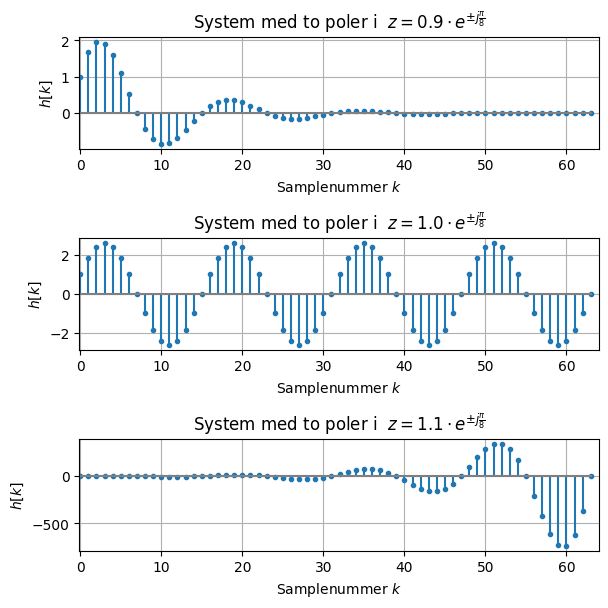

In [3]:
xk = np.zeros(64)
xk[0] = 1


r = [0.9, 1.0, 1.1] # Array med radius for polkoordinater innenfor, på & utenfor enhetssirkelen.

plt.close(4); plt.figure(4, figsize=(6,6))
for i in np.arange(3):
    plt.subplot(3,1,i+1)
    poles = r[i]*exp(1j*np.array([pi/8, -pi/8])) 
    b = [1]
    a = np.real(np.poly(poles))
    hk = sig.lfilter(b, a, xk)
    plt.stem(hk, markerfmt=".", basefmt="grey")
    plt.xlim([-0.1, len(xk)])
    plt.grid(True)
    plt.xlabel('Samplenummer $k$')
    plt.ylabel(r'$h[k]$')
    plt.title(r"System med to poler i  $z = "+str(r[i])+r"\cdot e^{\pm j \frac{\pi}{8}}$")
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

## Regneeksempel 1:

1. Et tidsdiskret system har transferfunksjonen 
$$H(z) = \frac{1 + z^{-1}}{1+0.7\cdot z^{-1}+0.49\cdot z^{-2}}$$
Finn filterets poler og nullpunkt, og skisser de i et pol- og nullpunktskart
2. Avgjør om systemet er stabilt

# Pol- og nullpuntkskart, 1. ordens system
<img src="figurer/Slide5.PNG" style="width: 70%" align="left" />

# Pol- og nullpunktskart 2. ordens system
<img src="figurer/Slide6.PNG" style="width: 70%" align="left"/>

# Poler og nullpunkt til transferfunksjon
* Faktorisering av transferfunksjonen gir:
$$H(z) = \frac{b_0}{a_0}\cdot \frac{(z-z_1)(z-z_2)\cdots(z-z_M)}{(z-p_1)(z-p_2)\cdots(z-p_N)}\cdot z^{N-M}$$
    * Her vil $\frac{b_0}{a_0}$ være et reelt tall som "skalerer" transferfunksjonen (ofte designert $K$).
    * $z_k$ angir filterets mulige nullpunkt for $k\in \{1 \ldots M\}$
    * $p_k$ angir filterets mulige poler for $k \in \{1 \ldots N\}$
    
* Differanseligningen til et system kan utledes fra et sett med poler og nullpunkt
* Systemets egenskaper kan tydes fra et sett med pol- og nullpunktskoordinater.

## Regneeksempel 2:

* Finn koeffisientene til *lavpasfilteret* med poler, nullpunkt og skaleringsfaktor som følger:
$$\begin{align} z_i &\in \{-1, -j, j\}\\
p_i &\in \left\{0.7\cdot e^{j\frac{\pi}{3}}, 0.7\cdot e^{-j\frac{\pi}{3}}\right\} \\
K &= 0.2
\end{align}$$


b =  [1. 1. 1. 1.] 
a =  [ 1.   -0.7   0.49] K =  1


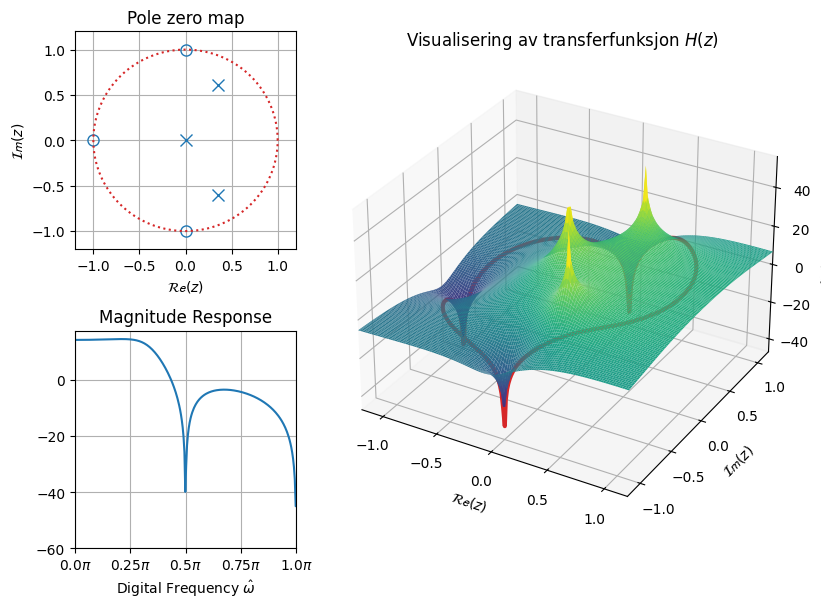

In [9]:
from demos import visualizeTF
zeroes = np.array([-1.0,
                   1j,
                   -1j])

poles = np.array([0.7*exp(1j*pi/3),
                  0.7*exp(-1j*pi/3)
                 ])

w_0 = 0 # Rad/sample
z_0 = 1*np.exp(1j*w_0)


b, a = sig.zpk2tf(zeroes, poles, 1)

visualizeTF(b, a, fig_num=4)
print("b = ", b, "\na = ", a, "K = ", 1)

# Transferfunksjon $\leftrightarrow$ pol- og nullpunktskoordinater i Python

* Nyttige funksjoner:
    * [`tf2zpk`](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.signal.tf2zpk.html) for å omforme arrays med filterkoeffisienter $a_i$ og $b_i$ til nullpunkt $z_i$, poler $p_i$ og skaleringsfaktor $K$.
    * [`zpk2tf`](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.signal.zpk2tf.html) for å omforme arrays med nullpunkt $z_i$, poler $p_i$ og skaleringsfaktor $K$ til filterkoeffisienter $a_i$ og $b_i$ til.

In [6]:
b = [1, 1]
a = [1, 0.7, 0.49]

z, p, K = sig.tf2zpk(b, a)
print(f"{z = }, {p = }, {K = }")

z = array([-1.]), p = array([-0.35+0.60621778j, -0.35-0.60621778j]), K = np.float64(1.0)


In [7]:
b, a = sig.zpk2tf(z, p, k)
print(f"{b = }, {a = }")

b = array([1., 1.]), a = array([1.  , 0.7 , 0.49])


# Spørsmål?